# Lista 5

## Pandas i Dask

(8pkt + 2pkt)

Na liście znajduje się 8 zadań. Po rozwiązaniu zadania pokaż kod prowadzącemu i odpowiedz na **pytanie kontrolne** — tylko wtedy przyznajemy punkty. Dodatkowo prześlij zadanie na platformie skos.

Zadanie dodatkowe oznaczone jest ⭐️. Za wykonanie zadania otrzymasz 2pkt.

### Pandas

Rozważ bazę danych z wykładu i rozwiąż poniższe zadania.

In [1]:
import numpy as np
import pandas as pd

N = 100000

data_ = np.random.randint(1000, size=(N, 4))

df = pd.DataFrame(data_, columns=['time', 'uid', 'pid', 'rating'])
df['time'] = np.random.randint(24 * 60 * 60, size=(N))
df['time'] = pd.to_datetime('2025-01-01') + pd.to_timedelta(1e9 * df['time'])
df['rating'] = np.random.randint(10, size=(N))

df.head()

,time,uid,pid,rating
0,2025-01-01 16:59:46,8,527,7
1,2025-01-01 07:43:44,910,754,5
2,2025-01-01 15:15:38,185,962,9
3,2025-01-01 08:13:15,160,636,5
4,2025-01-01 20:52:20,145,85,9


#### Zadanie 1

Dla każdego użytkownika znajdź produkt (`pid`), który ocenił najczęściej.

,uid,pid,count
105,0,978,3
143,1,414,2
195,2,96,2
331,3,445,3
431,4,365,3


#### Zadanie 2

Policz liczbę ocen w każdej godzinie dnia.

**Wskazówka**

Użyj `resample()`.

time
2025-01-01 00:00:00    4272
2025-01-01 01:00:00    4176
2025-01-01 02:00:00    4147
2025-01-01 03:00:00    4150
2025-01-01 04:00:00    4225
Freq: H, Name: rating, dtype: int64

#### Zadanie 3

Wybierz oceny użytkowników w godzinach pracy: od 8:00 do 16:00. Następnie dla każdego produktu (`pid`) policz: liczbę ocen, średnią i maksymalną ocenę.

In [ ]:
df.between_time()

,count,mean,max
pid,,,
0,44,4.590909,9
1,45,3.977778,9
2,23,3.608696,9
3,20,6.100000,9
4,25,4.600000,9


#### Zadanie 4

Przekształć kolumnę `rating` na słowa:

* 0–3 → "niska"
* 4–6 → "średnia"
* 7–9 → "wysoka"

**Wskazówka**

Użyj `map()`.

In [ ]:
def rating_label(x):
    if x <= 3:
        return 'niska'
    elif x <= 6:
        return 'średnia'
    else:
        return 'wysoka'


,rating,rating_label
time,,
2025-01-01 04:11:04,9,wysoka
2025-01-01 17:20:48,8,wysoka
2025-01-01 19:06:47,1,niska
2025-01-01 05:10:32,1,niska
2025-01-01 15:11:15,7,wysoka


#### Zadanie 5

Połącz tabelę *products* zawierającą nazwy produktów (`pid` → `product_name`) z głównym df.

In [ ]:
products = pd.DataFrame({
    'pid': df['pid'].unique(),
    'product_name': ['Produkt_' + str(i) for i in range(len(df['pid'].unique()))]
})

,time,uid,pid,rating,rating_label,product_name
0,2025-01-01 04:11:04,945,554,9,wysoka,Produkt_0
1,2025-01-01 17:20:48,201,117,8,wysoka,Produkt_1
2,2025-01-01 19:06:47,435,538,1,niska,Produkt_2
3,2025-01-01 05:10:32,799,26,1,niska,Produkt_3
4,2025-01-01 15:11:15,303,411,7,wysoka,Produkt_4


#### Zadanie 6

Policz, które produkty były najczęściej oceniane w poszczególnych godzinach. Zwizualizuj to na wykresie.

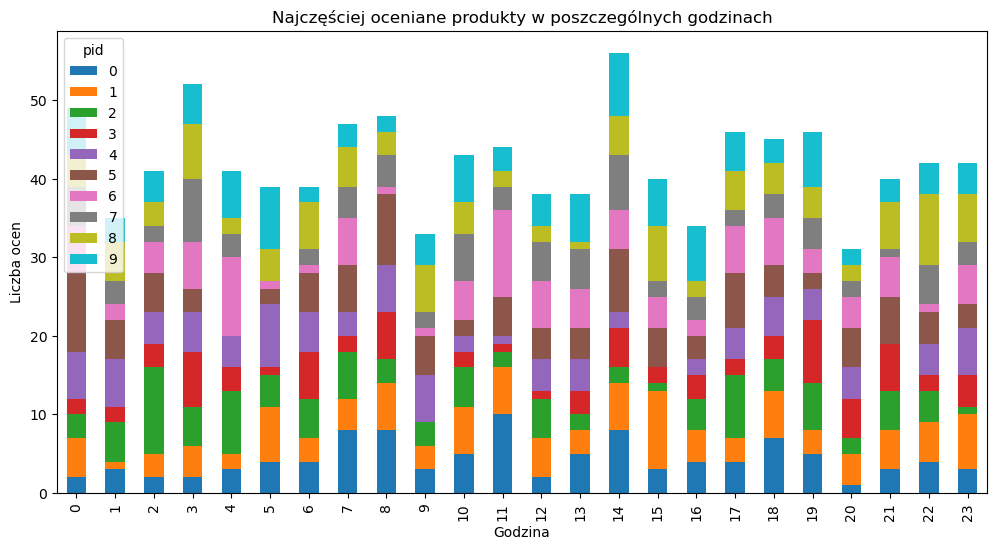

#### Zadanie 7

Utwórz dla każdego użytkownika sekwencję identyfikatorów produktów (`pid`), które ocenił, ale tylko produkty ocenione więcej niż 50 razy w godzinach od 8:00 do 16:00.

**Wskazówka**

Godzinę możesz wyodrębnić za pomocą:

```python
df['time'].dt.hour
```

uid
0          [594]
10    [247, 594]
11         [247]
15         [247]
21         [873]
Name: pid, dtype: object

#### Zadanie 8

Podziel produkty na 3 grupy według „stabilności ocen” (liczba ocen produktu) i policz średnią ocenę dla każdego użytkownika w kolejnych godzinach dnia, ale tylko dla produktów należących do 3. grupy (produkty z największą liczbą ocen).

**Wskazówka**

Może się przydać funkcja `qcut()`, `merge()`.

/var/folders/30/p871csfd59bg0hq53w_t9pw80000gn/T/ipykernel_3094/1091217139.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group3['hour'] = df_group3['time'].dt.hour


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
uid,,,,,,,,,,,,,,,,,,,,,
0,0.0,4.750000,4.5,0.000000,4.000000,1.0,0.0,7.0,4.000000,5.5,...,8.000000,0.0,0.000000,4.666667,3.25,6.000000,4.333333,3.800000,6.0,0.000000
1,0.0,0.000000,4.0,6.000000,0.000000,0.0,0.0,1.0,0.000000,2.0,...,5.000000,0.0,0.000000,0.000000,5.00,7.333333,3.000000,4.333333,0.0,0.000000
2,0.0,0.000000,0.0,0.000000,0.000000,0.0,4.5,8.0,0.000000,3.5,...,0.000000,0.0,3.000000,3.500000,8.00,7.333333,7.000000,7.500000,4.5,2.666667
3,3.5,2.666667,5.0,3.333333,1.333333,6.0,2.0,5.0,5.333333,9.0,...,3.500000,9.0,4.666667,4.000000,5.00,0.000000,1.000000,9.000000,3.0,0.000000
4,5.0,3.000000,0.0,0.000000,0.000000,4.5,4.0,1.0,0.000000,5.2,...,4.333333,5.0,0.000000,5.500000,2.00,0.000000,2.000000,0.000000,4.0,2.000000


### ⭐️ Dask

Wygenerujemy dane syntetyczne w Pandas i zapiszemy je do CSV.

In [10]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1_000_000

df = pd.DataFrame({
    "uid": np.random.randint(1, 100_000, size=n),
    "movie_id": np.random.randint(1, 5000, size=n),
    "rating": np.random.uniform(1, 5, size=n).round(2),
    "timestamp": pd.date_range("2020-01-01", periods=n, freq="min")
})

df.to_csv("ratings.csv", index=False)
print("Zapisano plik: ratings.csv")

Zapisano plik: ratings.csv


#### Zadanie 1 

Wczytaj dane z pliku *ratings.csv* do Dask DataFrame. Ile partycji ma wczytany plik? Sprawdź rozmiar danych (`memory_usage()`)

/Users/mariaszlasa/miniconda3/lib/python3.11/site-packages/dask/dataframe/_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 11.0.0. Please consider upgrading.
  warnings.warn(


     uid  movie_id  rating            timestamp
0  15796       448    2.95  2020-01-01 00:00:00
1    861      3227    3.55  2020-01-01 00:01:00
2  76821      3321    3.01  2020-01-01 00:02:00
3  54887       232    2.52  2020-01-01 00:03:00
4   6266      4622    4.68  2020-01-01 00:04:00
1
Index             128
uid           8000000
movie_id      8000000
rating        8000000
timestamp    76000000
dtype: int64


#### Zadanie 2

Oblicz średnią ocenę oraz policz liczbę ocen > 4.

248540

#### Zadanie 3

Pokaż, jak Dask rozkłada obliczenia na taski dla operacji:

```python
ddf.groupby("uid")["rating"].mean()
```

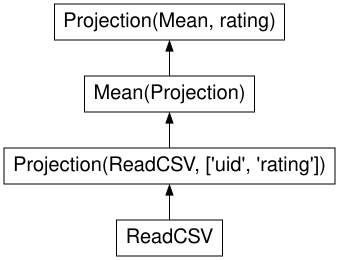

#### Zadanie 4

Znajdź 10 filmów z najwyższą średnią oceną (tylko jeśli mają >100 ocen). Niech wynik będzie zapisany w pamięci.

,mean,count
movie_id,,
621,3.353220,205
4224,3.331755,188
3736,3.293943,175
1048,3.293280,186
1500,3.284029,206
1417,3.274503,191
1626,3.273962,212
1735,3.272353,204
1227,3.271968,188
